Project Name: Employee Attrition Analyzer 
Name: Mohsin Ali
Roll no: 24F-AI-074

Importing Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

Load Dataset

In [32]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


check number of rows and columns info and check null values count for data cleaning

In [33]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

check total values in target column

In [34]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

I have removed these columns because these donn't provide any necessary information

In [35]:
df = df.drop(["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"], axis=1)

convert categorical columns

In [36]:
le = LabelEncoder()
for column in df.select_dtypes(include="object"):
    df[column] = le.fit_transform(df[column])
    
# now all columns are numerical 
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


separate X and Y

In [37]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]


data split 80% training and 20% testing

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

create and train logistic regression model
here max_iter=1000 allow Logistic Regression to repeat its learning process up to 1000 times.

In [39]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

c:\Users\123\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


check accuracy and f1 score for model performance
Accuracy tells us the overall percentage of correct predictions, while F1 score provides a better measure when the classes are imbalanced.

In [40]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Accuracy: 0.8673469387755102
F1 Score: 0.20408163265306123


check confusion matrix
The confusion matrix shows how many employees were correctly and incorrectly classified as staying or leaving.

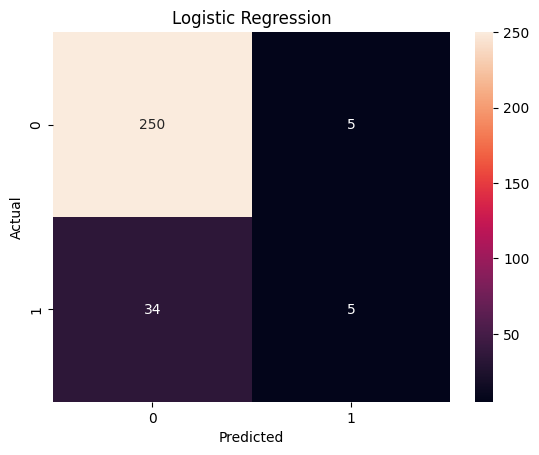

In [41]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression")
plt.show()

create and train decision tree model
Decision Tree makes predictions by creating a series of decisions based on employee features.

In [42]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

check accuracy and f1 score
These metrics measure how well the Decision Tree predicts employee attrition.

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

Accuracy: 0.7993197278911565
F1 Score: 0.23376623376623376


check confusion matrix
It shows the correct and incorrect predictions made by the Decision Tree for employees who stayed or left.

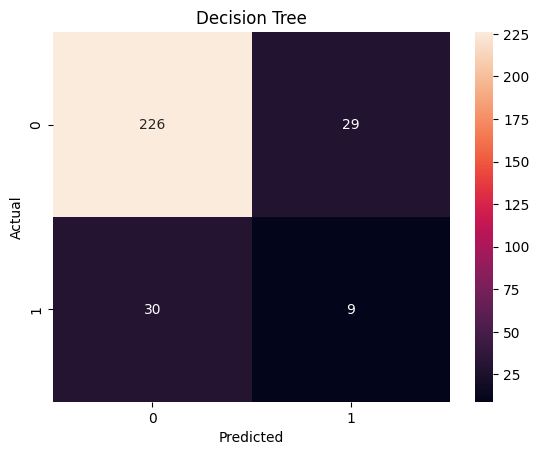

In [44]:
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree")
plt.show()

create and train random forest model
Random Forest combines multiple decision trees to make predictions. It can usually provide more stable predictions than using a single Decision Tree.

In [45]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

check accuracy and f1 score
These metrics show how accurately the Random Forest predicts employee attrition.

In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.8809523809523809
F1 Score: 0.2222222222222222


check confusion matrix
I used the confusion matrix to see how well the Random Forest correctly identifies employees who stay and employees who leave.

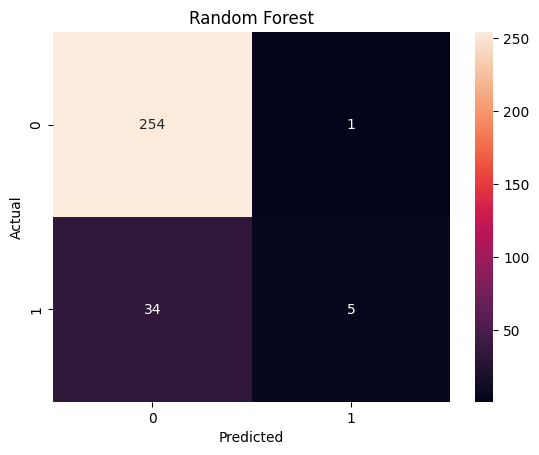

In [47]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest")
plt.show()

compare the models with their performance
I compared the three models to determine which algorithm performs best for employee attrition prediction.

In [48]:
print("Logistic Regression F1:", f1_score(y_test, y_pred_lr))
print("Decision Tree F1:", f1_score(y_test, y_pred_dt))
print("Random Forest F1:", f1_score(y_test, y_pred_rf))

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression F1: 0.20408163265306123
Decision Tree F1: 0.23376623376623376
Random Forest F1: 0.2222222222222222
Logistic Regression Accuracy: 0.8673469387755102
Decision Tree Accuracy: 0.7993197278911565
Random Forest Accuracy: 0.8809523809523809


Random forest feature importance
Feature importance tells us which employee characteristics contributed most to the Random Forest's predictions.
and visualization makes it easier to identify the employee features that have the greatest influence on attrition prediction.

MonthlyIncome         0.078212
OverTime              0.066669
Age                   0.061569
DailyRate             0.054087
TotalWorkingYears     0.052491
MonthlyRate           0.048373
HourlyRate            0.047369
DistanceFromHome      0.045999
YearsAtCompany        0.041347
NumCompaniesWorked    0.037951
dtype: float64


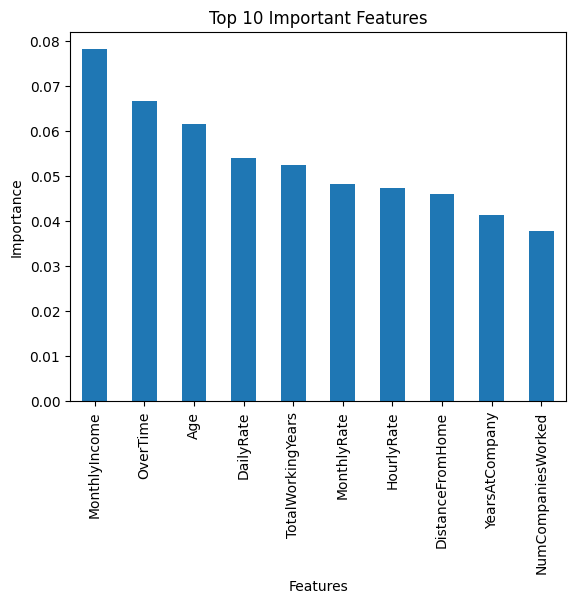

In [49]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)
print(importance.head(10))

importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()